# "What makes the Gold Standard?": Food.com Five Star Recipe Analysis and Prediction
Names: Adrianne See, Aarman Sachdev
Website: https://ag-see.github.io/Food-dot-com-Ratings-Prediction/

In [1]:
# Setup Cell, run once

# Import relevant modules
import pandas as pd
import numpy as np
from pathlib import Path

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif

# Adjust graphing module settings
sns.set(font_scale=1.2, style="white")
pd.options.plotting.backend = 'plotly'

#Load data
recipes = pd.read_csv('data/RAW_recipes.csv')
interactions = pd.read_csv('data/interactions.csv')

# Step 1: Introduction

In [2]:
# Print recipes dataset descriptions
print(f'Food.com recipes dataset sample contains {recipes.shape[0]} entries with {recipes.shape[1]} features\n')
print(f"Datatypes of recipes Dataset\n{recipes.dtypes}\n")
print(f"Null entries of recipes Dataset\n{recipes.isna().sum()}\n")
recipes.head()

Food.com recipes dataset sample contains 83782 entries with 12 features

Datatypes of recipes Dataset
name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object

Null entries of recipes Dataset
name               1
id                 0
minutes            0
contributor_id     0
submitted          0
tags               0
nutrition          0
n_steps            0
steps              0
description       70
ingredients        0
n_ingredients      0
dtype: int64



,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11
2,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9
3,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7
4,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13


In [3]:
# Print interactions dataset descriptions
print(f'Food.com interactions dataset sample contains {interactions.shape[0]} entries with {interactions.shape[1]} features\n')
print(f"Datatypes of interactions Dataset\n{interactions.dtypes}\n")
print(f"Null entries of interactions Dataset\n{interactions.isna().sum()}\n")
interactions.head()

Food.com interactions dataset sample contains 731927 entries with 5 features

Datatypes of interactions Dataset
user_id       int64
recipe_id     int64
date         object
rating        int64
review       object
dtype: object

Null entries of interactions Dataset
user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64



,user_id,recipe_id,date,rating,review
0,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
1,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
2,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."
3,124416,120345,2011-08-06,0,"Just an observation, so I will not rate. I fo..."
4,2000192946,120345,2015-05-10,2,This recipe was OVERLY too sweet. I would sta...


The Project changed several times, but questions brainstormed were

- Can we Predict "Healthy Recipes"?
- Can we predict "Recipe Ratings"
And the final one we landed on after EDA
- "Can we predict a Five Star Average Rating?"

## Step 2: Data Cleaning and Exploratory Data Analysis

In [4]:
# Data Cleaning
# Note this cell can only run once, if this cell causes errors, restart your kernel.

# Step 1: Left merge
merged = recipes.merge(interactions, left_on='id', right_on='recipe_id', how='left')

# Step 2: Fill ratings of 0 with NaN
merged['rating'] = merged['rating'].replace(0, np.nan)

# Step 3: Compute and assign average rating per recipe
avg_ratings = merged.groupby('recipe_id')['rating'].mean()
recipes = recipes.merge(avg_ratings.rename('avg_rating'), left_on='id', right_on='recipe_id', how='left')

# Step 4: Parse nutrition column into columns
recipes['nutrition'] = recipes['nutrition'].apply(eval)
# Expand nutrition column into separate columns
recipes[['calories', 'total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']] = pd.DataFrame(recipes['nutrition'].tolist(), index = recipes.index)

# Step 5: Transform PDV values into decimals
decimal_tf = lambda x: x/100
recipes[['total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']] = recipes[['total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']].apply(decimal_tf, axis = 1)

# Step 6: Parse tags column
recipes['tags'] = recipes['tags'].apply(eval)
recipes['ingredients'] = recipes['ingredients'].apply(eval)

# Step 7: Step Convert submitted to datetime year
recipes['submitted_year'] = pd.to_datetime(recipes['submitted']).dt.year

# Step 8: Create five_star column
recipes['five_star'] = recipes['avg_rating'] == 5.0

In [5]:
print(recipes.dtypes)
recipes.head()

name               object
id                  int64
minutes             int64
contributor_id      int64
submitted          object
tags               object
nutrition          object
n_steps             int64
steps              object
description        object
ingredients        object
n_ingredients       int64
avg_rating        float64
calories          float64
total_fat         float64
sugar             float64
sodium            float64
protein           float64
saturated_fat     float64
carbohydrates     float64
submitted_year      int32
five_star            bool
dtype: object


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,...,avg_rating,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates,submitted_year,five_star
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"[60-minutes-or-less, time-to-make, course, mai...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...",...,4.0,138.4,0.10,0.50,0.03,0.03,0.19,0.06,2008,False
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"[60-minutes-or-less, time-to-make, cuisine, pr...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,...,5.0,595.1,0.46,2.11,0.22,0.13,0.51,0.26,2011,True
2,412 broccoli casserole,306168,40,50969,2008-05-30,"[60-minutes-or-less, time-to-make, course, mai...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,...,5.0,194.8,0.20,0.06,0.32,0.22,0.36,0.03,2008,True
3,millionaire pound cake,286009,120,461724,2008-02-12,"[time-to-make, course, cuisine, preparation, o...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,...,5.0,878.3,0.63,3.26,0.13,0.20,1.23,0.39,2008,True
4,2000 meatloaf,475785,90,2202916,2012-03-06,"[time-to-make, course, main-ingredient, prepar...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...",...,5.0,267.0,0.30,0.12,0.12,0.29,0.48,0.02,2012,True


### Univariate Analysis

0.9420519920746699


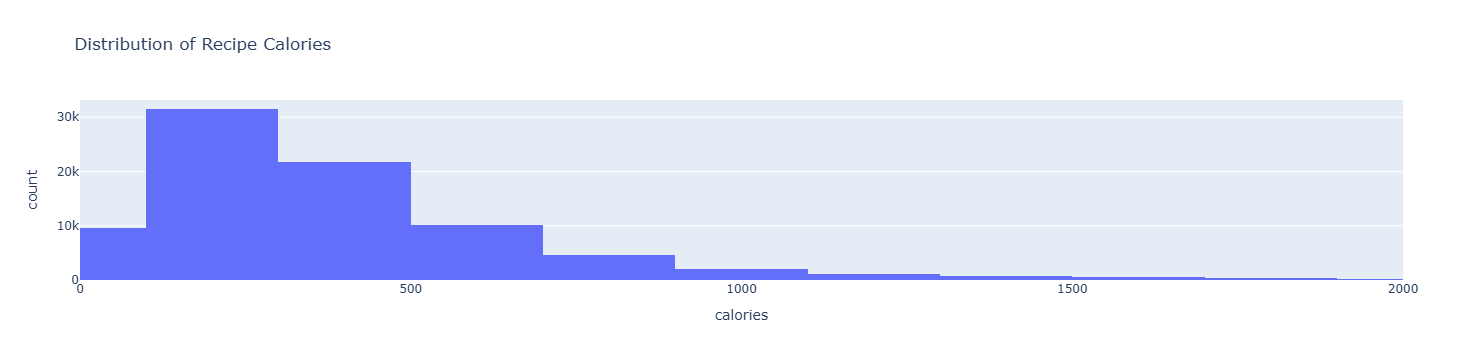

count    83782.000000
mean       429.926989
std        636.628493
min          0.000000
25%        171.325000
50%        305.400000
75%        498.700000
max      45609.000000
Name: calories, dtype: float64

In [6]:
# Plot distribution of calories
print(recipes[recipes['calories'] < 1000].shape[0] / recipes.shape[0])
fig = px.histogram(recipes, x='calories', title='Distribution of Recipe Calories', nbins=250)
fig.update_xaxes(range=[0, 2000])
fig.show()

# Save Graph
fig.write_html('assets/uni-calories.html', include_plotlyjs='cdn')

# Describe summary statistics on the 'calories' column
recipes['calories'].describe()

### Bivariate Analysis

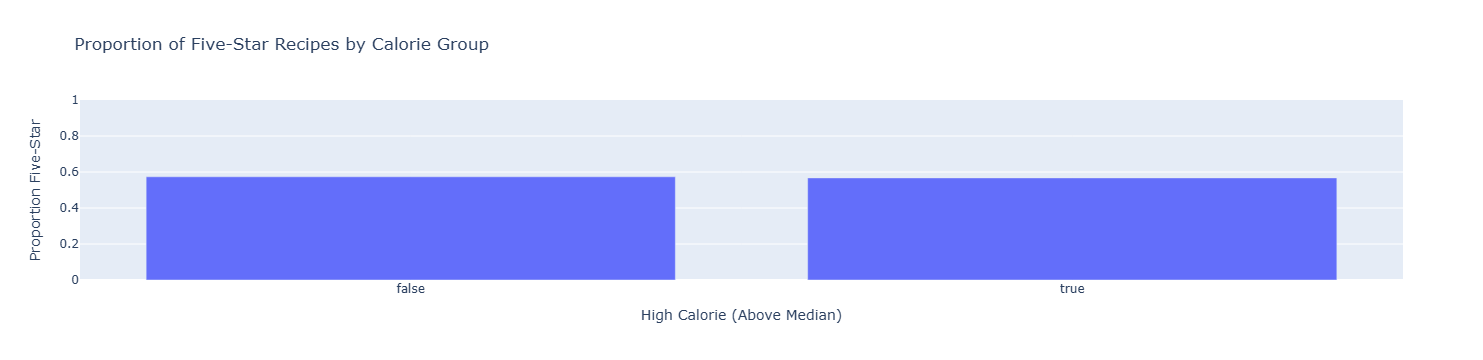

In [8]:
# Create high/low calorie groups and compare ratings
recipes['high_calorie'] = recipes['calories'] > recipes['calories'].median()

prop_df = recipes.groupby('high_calorie')['five_star'].mean().reset_index()

# Plot results
fig = px.bar(
    prop_df,
    x='high_calorie',
    y='five_star',
    title='Proportion of Five-Star Recipes by Calorie Group',
    labels={
        'high_calorie': 'High Calorie (Above Median)',
        'five_star': 'Proportion Five-Star'
    })
fig.update_yaxes(range=[0, 1])
fig.show()

# Save Graph
fig.write_html('assets/bivariate-rating-calorie.html', include_plotlyjs='cdn')

### Interesting Aggregates

In [9]:
# Group by n_ingredients and compute mean and median for calories, total fat, and avg_rating
metrics = ['mean', 'median']
agg = recipes.groupby('n_ingredients')[['calories', 'total_fat', 'avg_rating']].agg({
    'calories': metrics,
    'total_fat': metrics,
    'avg_rating': metrics
}).round(2)

agg.head(10)

calories         total_fat        avg_rating       
                  mean  median      mean median       mean median
n_ingredients                                                    
1               714.65  200.35      0.91   0.03       4.86    5.0
2               331.98  148.10      0.26   0.03       4.69    5.0
3               306.11  166.70      0.22   0.06       4.66    5.0
4               336.01  195.60      0.24   0.09       4.63    5.0
5               347.80  224.20      0.25   0.13       4.65    5.0
6               355.89  245.55      0.26   0.15       4.63    5.0
7               391.13  272.30      0.30   0.18       4.62    5.0
8               387.03  290.90      0.30   0.20       4.61    5.0
9               422.50  306.55      0.32   0.21       4.61    5.0
10              449.82  322.00      0.35   0.22       4.61    5.0

## Step 3: Assessment of Missingness



We analyzed the missingness of `avg_rating`, which has 2,609 missing values. A recipe has a missing `avg_rating` if no users have rated it.

We tested whether the missingness of `avg_rating` depends on `calories`, `n_ingredients`, and `minutes` using permutation tests with the difference in means as our test statistic.

| Column | Observed Difference | P-value |
|--------|-------------------|---------|
| minutes | 117.342 | 0.0000 |
| n_steps | 1.493 | 0.0000 |
| calories | 87.859 | 0.0000 |

All three p-values are essentially 0, meaning we reject the null hypothesis that the missingness of `avg_rating` is independent of these columns. Recipes with missing ratings tend to have higher calories, more ingredients, and longer prep times. This suggests the missingness of `avg_rating` is **MAR** — dependent on other observed columns.

In [10]:
# Check missignness in dataset
print(recipes.isnull().sum())
print(recipes.columns)

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description         70
ingredients          0
n_ingredients        0
avg_rating        2609
calories             0
total_fat            0
sugar                0
sodium               0
protein              0
saturated_fat        0
carbohydrates        0
submitted_year       0
five_star            0
high_calorie         0
dtype: int64
Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients', 'avg_rating', 'calories', 'total_fat', 'sugar',
       'sodium', 'protein', 'saturated_fat', 'carbohydrates', 'submitted_year',
       'five_star', 'high_calorie'],
      dtype='object')


### Missingness Dependency

In [11]:
# Add a column indicating if avg_rating is missing
recipes['rating_missing'] = recipes['avg_rating'].isna()

# Compare distributions of calories and n_ingredients by missingness
print(recipes.groupby('rating_missing')[['calories', 'n_ingredients', 'minutes']].mean())

                  calories  n_ingredients     minutes
rating_missing                                       
False           427.191020       9.206103  111.376862
True            515.050326       9.460330  228.719049


In [12]:
# Missingness depending section

# Define permutatuion test function
def permutation_test(col, n=1000):
    observed = np.abs(recipes.groupby('rating_missing')[col].mean().diff().iloc[-1])
    diffs = []

    for _ in range(n):
        shuffled = np.random.permutation(recipes['rating_missing'])
        diff = np.abs(
            recipes[col]
            .groupby(shuffled)
            .mean()
            .diff()
            .iloc[-1]
        )
        diffs.append(np.abs(diff))

    p_value = np.mean(np.array(diffs) >= observed)
    return observed, p_value, diffs

# Run permutation tests and store results
results = {}
for col in ['minutes', 'n_steps', 'calories', 'submitted_year']:
    obs, p_value, diffs = permutation_test(col)
    results[col] = {'observed': obs,'p_value': p_value,'diffs': diffs}

    print(f'\n{col}')
    print(f'Observed Difference: {obs:.3f}')
    print(f'P-value: {p_value:.4f}')

# Define cutoff for graph. If this doesn't get executed, the graph glitches from outliers
minutes_cutoff = recipes['minutes'].quantile(0.99)

# Plot data
plot_data = recipes[recipes['minutes'] <= minutes_cutoff]
fig = px.histogram(
    plot_data,
    x='minutes',
    color='rating_missing',
    histnorm='probability density',
    barmode='overlay',
    opacity=0.6,
    title='Distribution of Cooking Time by Rating Missingness'
)

fig.show()

# Save Graph
fig.write_html('assets/nmar-cooking.html', include_plotlyjs='cdn')


minutes
Observed Difference: 117.342
P-value: 0.0440

n_steps
Observed Difference: 1.493
P-value: 0.0000

calories
Observed Difference: 87.859
P-value: 0.0000

submitted_year
Observed Difference: 0.730
P-value: 0.0000


In [13]:
# Missingness independent section

# Split binary groups for missing description
recipes['description_missing'] = recipes['description'].isna()

# Perform permutation test
obs, p_value, diffs = permutation_test('description_missing')

# Output results
print(f'Observed Difference: {obs:.3f}')
print(f'P-value: {p_value:.4f}')

# Create dataframe for null distribution
df_null = pd.DataFrame({
    "diff": diffs
})

# Graph
fig = px.histogram(
    df_null,
    x="diff",
    nbins=30,
    title="'avg_rating' Missingness Dependence (Null Distribution)",
    labels={"diff": "Absolute Difference in Proportions"},
)

# Add observed statistic as vertical line
fig.add_vline(
    x=obs,
    line_width=3,
    line_color="red",
    annotation_text=f"Observed = {obs:.3f}",
    annotation_position="top right"
)

fig.show()
fig.write_html('assets/missingness-description.html', include_plotlyjs='cdn')

Observed Difference: 0.001
P-value: 0.2820


## Step 4: Hypothesis Testing

Observed diff: -0.036016450047030135
P-value: 1.0
Observed diff: -0.036016450047030135
P-value: 0.0


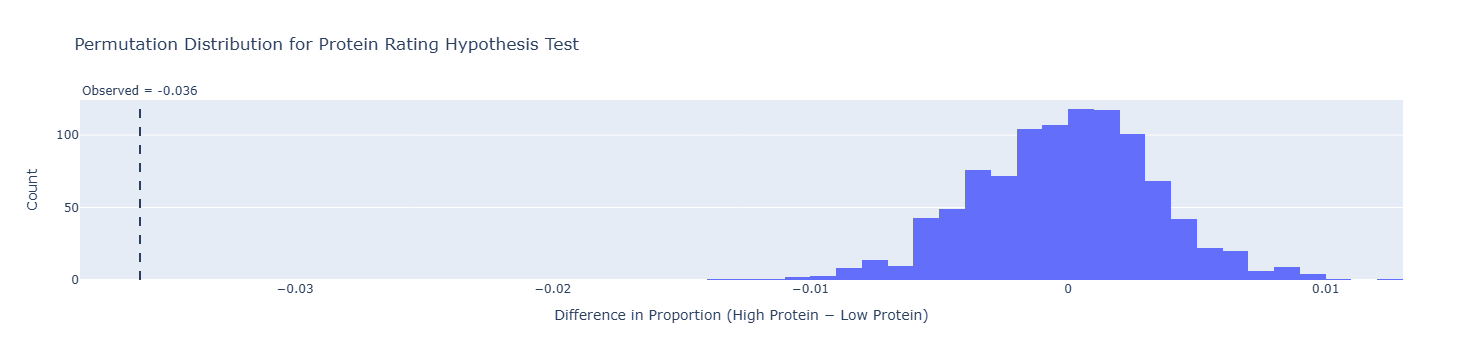

In [14]:
# Split into high and low protein groups
median_protein = recipes['protein'].median()

high_protein = recipes[recipes['protein'] > median_protein]['five_star']
low_protein = recipes[recipes['protein'] <= median_protein]['five_star']

# Calculate Observed difference
observed_diff = high_protein.mean() - low_protein.mean()

# Perform Permutation test

protein = recipes['protein'].to_numpy()
five_star = recipes['five_star'].to_numpy()

n = len(recipes)

diffs = np.empty(1000)

for i in range(1000):
    perm_idx = np.random.permutation(n)

    shuffled_protein = protein[perm_idx]

    median = np.median(shuffled_protein)

    high = five_star[shuffled_protein > median].mean()
    low = five_star[shuffled_protein <= median].mean()

    diffs[i] = high - low

# Compute p-value
p_value_a = np.mean(diffs >= observed_diff)
p_value_b = np.mean(diffs <= observed_diff)

# Print results
print('Observed diff:', observed_diff)
print('P-value:', p_value_a)

#Print alternate results
print('Observed diff:', observed_diff)
print('P-value:', p_value_b)

# Plot permutation distribution
fig = px.histogram(
    x=diffs,
    nbins=40,
    title='Permutation Distribution for Protein Rating Hypothesis Test',
    labels={
        'x': 'Difference in Proportion of 5-Star Recipes'
    }
)

fig.add_vline(
    x=observed_diff,
    line_dash='dash',
    annotation_text=f'Observed = {observed_diff:.3f}',
    annotation_position='top')
fig.update_layout(xaxis_title='Difference in Proportion (High Protein − Low Protein)',yaxis_title='Count')

fig.show()

fig.write_html('assets/protein-hypothesis-test.html',include_plotlyjs='cdn')

## Step 5: Framing a Prediction Problem

(Final draft contained here)

The prediction task we set out was:

> **Can we predict whether a recipe will achieve a perfect five-star average rating?**

This is a **binary classification problem**.

## Response Variable

`five_star`

We chose this because understanding what makes a recipe five stars is directly useful for recommending and developing recipes people will enjoy. 

## Evaluation Metric

**F1-score**

The dataset contains more five-star recipes than non-five-star recipes, making F1-score a better measure than accuracy because it balances precision and recall.

## Features Available at Prediction Time

Only information available when a recipe is submitted was used:

* Nutritional information
* Preparation time
* Number of ingredients
* Number of steps
* Tags
* Ingredient lists
* Submission year

User reviews and ratings were excluded because they occur after publication.

## Step 6: Baseline Model

In [15]:
# Drop rows with missing avg_rating
model_data = recipes.dropna(subset=['avg_rating']).copy()

# Features and target
features = ['calories', 'n_steps', 'n_ingredients', 'minutes', 'total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']
X = model_data[features]
y = model_data['five_star']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline pipeline
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter = 1000, class_weight = 'balanced'))
])

baseline.fit(X_train, y_train)

y_train_pred = baseline.predict(X_train)
y_test_pred = baseline.predict(X_test)

# Metrics
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print("Train F1:", train_f1)
print("Test F1:", test_f1)
print("Precision:", precision)
print("Recall:", recall)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Train F1: 0.5298462826724086
Test F1: 0.527683007122763
Precision: 0.6165034965034965
Recall: 0.46123260437375746

Classification Report:
              precision    recall  f1-score   support

       False       0.43      0.59      0.50      6678
        True       0.62      0.46      0.53      9557

    accuracy                           0.51     16235
   macro avg       0.52      0.53      0.51     16235
weighted avg       0.54      0.51      0.52     16235



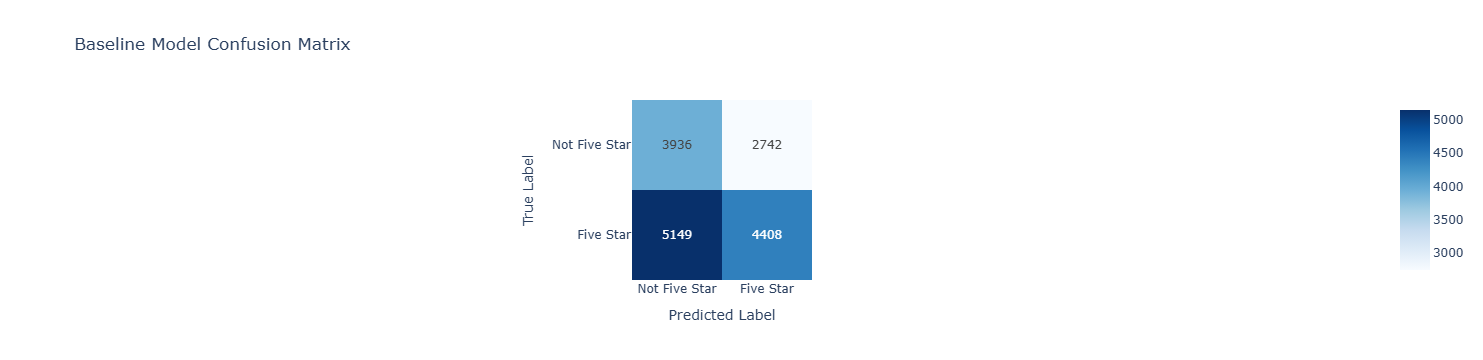

In [16]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Change Labels
labels = ["Not Five Star", "Five Star"]

# Make graph
fig = px.imshow(
    cm,
    text_auto=True,
    x=labels,
    y=labels,
    color_continuous_scale="Blues",
    title="Baseline Model Confusion Matrix"
)

fig.update_layout(
    xaxis_title="Predicted Label",
    yaxis_title="True Label"
)

fig.show()

# Export
fig.write_html('assets/baseline-confusion.html',include_plotlyjs='cdn')

## Step 7: Final Model

In [17]:
# Engineer ingredients into a usable text document
model_data['ingredient_text'] = model_data['ingredients'].apply(lambda lst: ' '.join(ingredient.lower().replace(' ', '_') for ingredient in lst))

# Engineer tags into a usable text document
model_data['tag_text'] = model_data['tags'].apply(lambda x: ' '.join(x).lower())

# Define numeric features separately
numeric_features = [
    'calories',
    'n_steps',
    'n_ingredients',
    'minutes',
    'total_fat',
    'sugar',
    'sodium',
    'protein',
    'saturated_fat',
    'carbohydrates',
    'submitted_year'
]

# Define text features separately
text_features = ['ingredient_text', 'tag_text']

# Assign parameter grid to perform KBest tests on
param_grid = {
    'kbest__k': [50, 100, 200, 300],
    'model__C': [0.01, 0.1, 1, 10, 100]
}

# Setup preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('ingredients', TfidfVectorizer(max_features=300), 'ingredient_text'),
    ('tags', TfidfVectorizer(max_features=100), 'tag_text')
])

X = model_data[numeric_features + text_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create final model
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('kbest', SelectKBest(score_func=f_classif)),
    ('model', LogisticRegression(max_iter=2000,class_weight='balanced'))
])

# Define GridSearchCV
grid = GridSearchCV(final_model,param_grid,scoring='f1',cv=5,n_jobs=-1)

# Fit on training dataset]
grid.fit(X_train, y_train)

# Predict
y_pred = grid.predict(X_test)

best_model = grid.best_estimator_

# Print Data
print(grid.best_params_)
print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

{'kbest__k': 300, 'model__C': 10}
F1: 0.6036902875254698
Precision: 0.6575021575638023
Recall: 0.5580202992570891


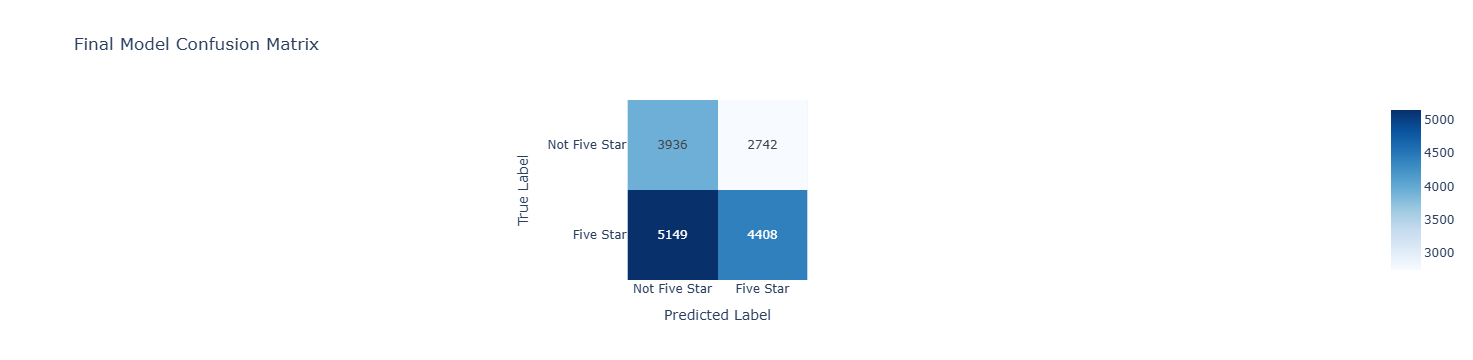

In [18]:
cm = confusion_matrix(y_test, y_test_pred)

# Change Labels
labels = ["Not Five Star", "Five Star"]

# Plotly heatmap
fig = px.imshow(
    cm,
    text_auto=True,
    x=labels,
    y=labels,
    color_continuous_scale="Blues",
    title="Final Model Confusion Matrix"
)

fig.update_layout(
    xaxis_title="Predicted Label",
    yaxis_title="True Label"
)

fig.show()
fig.write_html('assets/final-model-confusion.html',include_plotlyjs='cdn')

## Step 8: Fairness Analysis

In [19]:
# Create Median Year
median_year = model_data['submitted_year'].median()
print(median_year)

#Split submitted year into older and newer recipes
older_mask = X_test['submitted_year'] <= median_year
newer_mask = X_test['submitted_year'] > median_year

# Store f1 score on older and newere recipes
f1_old = f1_score(y_test[older_mask],y_pred[older_mask])
f1_new = f1_score(y_test[newer_mask],y_pred[newer_mask])

# Calculate obnserved difference
observed_diff = np.abs(f1_old - f1_new)

print("Older recipe F1:", f1_old)
print("Newer recipe F1:", f1_new)
print("Observed Difference:", observed_diff)

# Perform permutation test, old recipe gets assigned to True and newer is False
group_labels = older_mask.copy()
diffs = []

for i in range(1000):
    shuffled_labels = np.random.permutation(group_labels)
    f1_old_perm = f1_score(y_test[shuffled_labels],y_pred[shuffled_labels])
    f1_new_perm = f1_score(y_test[~shuffled_labels],y_pred[~shuffled_labels])
    diffs.append(abs(f1_old_perm - f1_new_perm))

# Calculate P value
p_value = np.mean(np.array(diffs) >= observed_diff)
print("P-value:", p_value)

# Graph results
perm_df = pd.DataFrame({'Difference in F1': diffs})

fig = px.histogram(
    perm_df,
    x='Difference in F1',
    nbins=30,
    title='Difference in F1 Scores Between Recipe Age Groups'
)

fig.add_vline(
    x=observed_diff,
    line_dash='dash',
    annotation_text=f'Observed = {observed_diff:.4f}',
    annotation_position='top'
)

fig.update_layout(
    xaxis_title='Absolute Difference in F1 Scores',
    yaxis_title='Count'
)

fig.show()
fig.write_html('assets/recipe-age.html',include_plotlyjs='cdn')

2009.0
Older recipe F1: 0.49571020019065776
Newer recipe F1: 0.7276042299744743
Observed Difference: 0.2318940297838165
P-value: 0.0
